Upload IMDB Dataset.csv


Saving IMDB Dataset.csv to IMDB Dataset (3).csv
Shape: (50000, 2)
Missing values:
 review       0
sentiment    0
dtype: int64
Duplicates: 418
Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Shape after removing duplicates: (49582, 2)


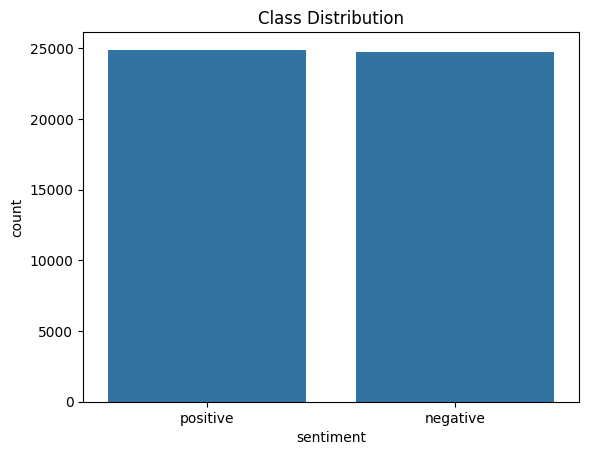

Extracting features...
Epoch 0, Loss: 0.6931
Epoch 20, Loss: 0.6926
Epoch 40, Loss: 0.6916
Epoch 60, Loss: 0.6888
Epoch 80, Loss: 0.6809
Epoch 100, Loss: 0.6613
Epoch 120, Loss: 0.6216
Epoch 140, Loss: 0.5693
Epoch 160, Loss: 0.5292
Epoch 180, Loss: 0.5082
Epoch 200, Loss: 0.4979
Epoch 220, Loss: 0.4921
Epoch 240, Loss: 0.4883
Epoch 260, Loss: 0.4855
Epoch 280, Loss: 0.4834
Epoch 300, Loss: 0.4818
Epoch 320, Loss: 0.4806
Epoch 340, Loss: 0.4797
Epoch 360, Loss: 0.4790
Epoch 380, Loss: 0.4784
Epoch 400, Loss: 0.4780
Epoch 420, Loss: 0.4776
Epoch 440, Loss: 0.4774
Epoch 460, Loss: 0.4772
Epoch 480, Loss: 0.4770
Epoch 500, Loss: 0.4768
Epoch 520, Loss: 0.4767
Epoch 540, Loss: 0.4766
Epoch 560, Loss: 0.4765
Epoch 580, Loss: 0.4764
Epoch 600, Loss: 0.4763
Epoch 620, Loss: 0.4763
Epoch 640, Loss: 0.4762
Epoch 660, Loss: 0.4762
Epoch 680, Loss: 0.4761
Epoch 700, Loss: 0.4761
Epoch 720, Loss: 0.4760
Epoch 740, Loss: 0.4760
Epoch 760, Loss: 0.4760
Epoch 780, Loss: 0.4760
Epoch 800, Loss: 0.4759

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Everything completed successfully!


In [11]:
!pip install vaderSentiment textblob seaborn --quiet

# 1. Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import pickle

np.random.seed(42)

os.makedirs("model", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 2. Upload Dataset
print("Upload IMDB Dataset.csv")
uploaded = files.upload()
df = pd.read_csv("IMDB Dataset.csv")

# 3. EDA
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Class distribution:\n", df['sentiment'].value_counts())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()

# 4. Preprocessing
df['review'] = df['review'].str.lower().str.strip()
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# 5. Feature Engineering
analyzer = SentimentIntensityAnalyzer()

def extract_features(text):
    scores = analyzer.polarity_scores(text)
    blob_score = TextBlob(text).sentiment.polarity
    return [
        scores['compound'],
        scores['pos'],
        scores['neg'],
        scores['neu'],
        blob_score
    ]

print("Extracting features...")
X = np.array([extract_features(r) for r in df['review']])
y = df['sentiment'].values.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. MLP Definition

n_x = X_train.shape[1]
n_h = 16
n_y = 1

W1 = np.random.randn(n_x, n_h) * 0.01
b1 = np.zeros((1, n_h))
W2 = np.random.randn(n_h, n_y) * 0.01
b2 = np.zeros((1, n_y))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# 7. Training

learning_rate = 0.1
epochs = 1000
m = X_train.shape[0]

losses = []

for epoch in range(epochs):

    Z1 = np.dot(X_train, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    loss = - (1/m) * np.sum(
        y_train*np.log(A2+1e-8) + (1-y_train)*np.log(1-A2+1e-8)
    )
    losses.append(loss)

    dZ2 = A2 - y_train
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1/m) * np.dot(X_train.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# 8. Evaluation

Z1_test = np.dot(X_test, W1) + b1
A1_test = relu(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

y_pred = (A2_test >= 0.5).astype(int)

accuracy = np.mean(y_pred == y_test)
print("\nTest Accuracy:", accuracy)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", cm)

# 9. Save Confusion Matrix

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png")
plt.close()

# 10. Save Loss Curves

plt.figure(figsize=(6,5))
plt.plot(losses)
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("results/loss_curves.png")
plt.close()

# 11. Save Metrics

with open("results/metrics.txt", "w") as f:
    f.write("Manual MLP (1 Hidden Layer)\n\n")
    f.write(f"Test Accuracy: {accuracy}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

# 12. Save Discussion

with open("results/results_discussion.txt", "w") as f:
    f.write("Results Discussion\n\n")
    f.write(f"Test Accuracy: {accuracy}\n\n")
    f.write("The model was implemented manually using forward pass,\n")
    f.write("binary cross-entropy loss, backpropagation and gradient descent.\n")
    f.write("The dataset is balanced and loss decreases steadily.\n")
    f.write("Using only lexicon features limits performance.\n")

# 13. Save Model (Original Folder Save)

model_params = {
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2
}

with open("model/best_model.pkl", "wb") as f:
    pickle.dump(model_params, f)

print("Model saved inside 'model/' folder.")


pickle.dump(model_params, open("best_model.pkl", "wb"))
print("Model also saved in root directory.")

print("Files in root:", os.listdir())
print("Files in model folder:", os.listdir("model"))

!zip -r FINAL_SUBMISSION.zip best_model.pkl results > /dev/null

print("Zip file created successfully!")

from google.colab import files
files.download("FINAL_SUBMISSION.zip")

print("\nEverything completed successfully!")
